In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../data/credito.csv")
df.head()



,id_contrato,idade,renda_mensal,tempo_emprego_anos,score_credito,dividas_ativas,possui_imovel,finalidade,prazo_meses,valor_emprestimo,inadimplente
0,E00001,44.0,4810.0,3.3,645.0,0,sim,negocio,60,7800.0,0
1,E00002,28.0,4070.0,1.1,805.0,3,nao,pessoal,24,7100.0,0
2,E00003,49.0,7050.0,5.2,563.0,1,sim,veiculo,48,29000.0,0
3,E00004,51.0,6040.0,0.8,778.0,1,sim,pessoal,24,21400.0,0
4,E00005,18.0,1300.0,2.4,551.0,0,nao,negocio,24,4700.0,1


In [3]:
y = df["inadimplente"]
X = df.drop(columns=["inadimplente", "id_contrato"])

In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [5]:
features_numericas = [
    "idade",
    "renda_mensal",
    "tempo_emprego_anos",
    "score_credito",
    "dividas_ativas",
    "prazo_meses",
    "valor_emprestimo"
]

features_categoricas = [
    "possui_imovel",
    "finalidade"
]

In [6]:
pipeline_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipeline_categorica = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessador = ColumnTransformer([
    ("numericos", pipeline_numerico, features_numericas),
    ("categoricos", pipeline_categorica, features_categoricas)
])


In [7]:
pipeline = Pipeline([
    ("preprocessador", preprocessador),
    ("modelo", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_treino, y_treino)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['idade','renda_mensal','tempo_emprego_anos',...,'finalidade', 'prazo_meses','valor_emprestimo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericos', ...), ('categoricos', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [8]:
y_pred = pipeline.predict(X_teste)  # Classificação final: 0 ou 1
y_prob = pipeline.predict_proba(X_teste)[:, 1]  # Probabilidade de ser 1

resultado = pd.DataFrame({
    "Probabilidade": y_prob,
    "" : "-",
    "Previsão": y_pred
})

print(resultado.head(20))

    Probabilidade     Previsão
0        0.252002  -         0
1        0.068364  -         0
2        0.097273  -         0
3        0.094345  -         0
4        0.040910  -         0
5        0.309932  -         0
6        0.109333  -         0
7        0.146125  -         0
8        0.007366  -         0
9        0.174597  -         0
10       0.251590  -         0
11       0.202596  -         0
12       0.099804  -         0
13       0.012152  -         0
14       0.241331  -         0
15       0.113376  -         0
16       0.149906  -         0
17       0.061363  -         0
18       0.116967  -         0
19       0.007149  -         0


In [9]:
acuracia = accuracy_score(y_teste, y_pred)                                           # Percentual geral de previsões corretas
precisao = precision_score(y_teste, y_pred)                                          # Dos previstos como inadimplentes, quantos realmente eram
recall = recall_score(y_teste, y_pred)                                               # Dos inadimplentes reais, quantos o modelo identificou
f1 = f1_score(y_teste, y_pred)                                                       # Equilíbrio entre precisão e recall
roc_auc = roc_auc_score(y_teste, y_prob)                                             # Capacidade do modelo de separar as duas classes

precision_curve, recall_curve, thresholds = precision_recall_curve(y_teste, y_prob)  # Precisão e recall para diferentes threshold
                                                  
pr_auc = auc(recall_curve, precision_curve)                                          # Área sob a curva Precision-Recall

print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

Acurácia: 0.8075
Precisão: 0.5714
Recall: 0.2131
F1-score: 0.3104
ROC AUC: 0.7612
PR AUC: 0.4759


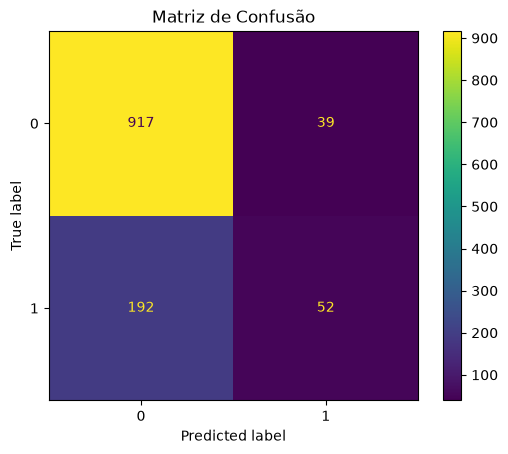

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred
)

plt.title("Matriz de Confusão")
plt.show()

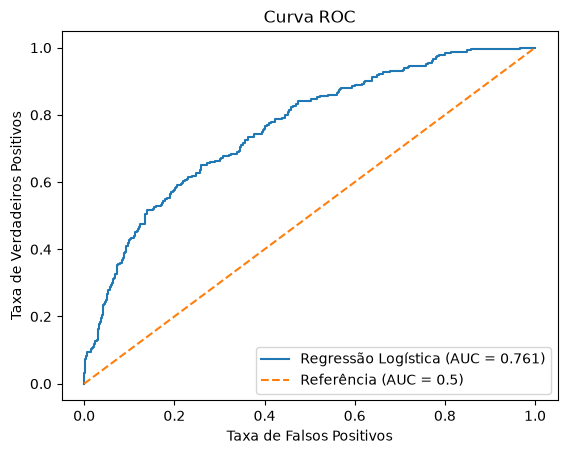

In [11]:
# Calcula as taxas da curva ROC para diferentes thresholds
fpr, tpr, thresholds = roc_curve(y_teste, y_prob)

# Curva do modelo e linha de referência
plt.plot(fpr, tpr, label=f"Regressão Logística (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Referência (AUC = 0.5)")

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC")
plt.legend()

plt.show()